In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 
import statsmodels.api as sm
from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from matplotlib.colors import LinearSegmentedColormap

In [3]:
# Define paths
mcds_path = '/ceph/MethDev/pbio/hazel/gene_mcds/gene'
rna_path = '/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv'
meta_path = '/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [4]:
import pandas as pd

# Load the text file directly into a Pandas Index
hazel_genes = pd.read_csv("extracted_c1038_genes.txt", header=None)[0]
hazel_genes = pd.Index(hazel_genes)

print(f"Loaded {len(hazel_genes)} genes ready for analysis.")

Loaded 1038 genes ready for analysis.


In [5]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# Aggregate by cluster
rna_log1p['cluster'] = meta.loc[common_cells, 'merged_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 17)


In [6]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

mCGN_mc['cluster'] = meta['merged_cluster']
mCGN_cov['cluster'] = meta['merged_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13764, 17)


In [8]:

# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# We will use the total coverage (cluster_m) as our weights
final_weights_df = cluster_m.loc[common_genes]

correlations = []
p_values = []
valid_genes = []

for gene in common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        # Endog (Y) = RNA, Exog (X) = Methylation
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        # Extract the slope coefficient (pseudo-rho) and its p-value
        # Index 1 is the slope for 'meth_z' (Index 0 is the constant)
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        # Catch any convergence errors for extremely sparse genes
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction
stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]

print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
print(stats_df.sort_values('rho').head(20))

Top 20 negatively correlated genes (WLS, Coverage-Weighted):
                rho   p_value       fdr
gene                                   
AT2G04790 -1.732238  0.000114  0.032653
AT2G07713 -1.663293  0.047919  0.496955
AT1G55370 -1.634012  0.000215  0.045561
AT5G35490 -1.449742  0.000016  0.008352
AT3G29639 -1.407684  0.003538  0.209529
AT2G04825 -1.384154  0.003283  0.206739
AT1G52240 -1.302113  0.001152  0.122335
AT3G21670 -1.298125  0.000027  0.011065
AT3G55735 -1.297038  0.000452  0.069419
AT3G26290 -1.294671  0.000006  0.004282
AT5G49740 -1.251251  0.000018  0.008440
AT2G05615 -1.246359  0.018173  0.376778
AT4G04330 -1.238686  0.014208  0.341467
AT3G29033 -1.235975  0.041621  0.471824
AT4G04265 -1.222466  0.010509  0.302969
AT5G23060 -1.201050  0.020242  0.387271
AT2G07764 -1.197692  0.272472  0.744871
AT5G57760 -1.196886  0.000578  0.081813
AT1G58290 -1.196723  0.000166  0.039083
AT4G38870 -1.191051  0.002114  0.173913


Processing: 1_All_Clusters...
  -> Found 23 significant inverse genes.


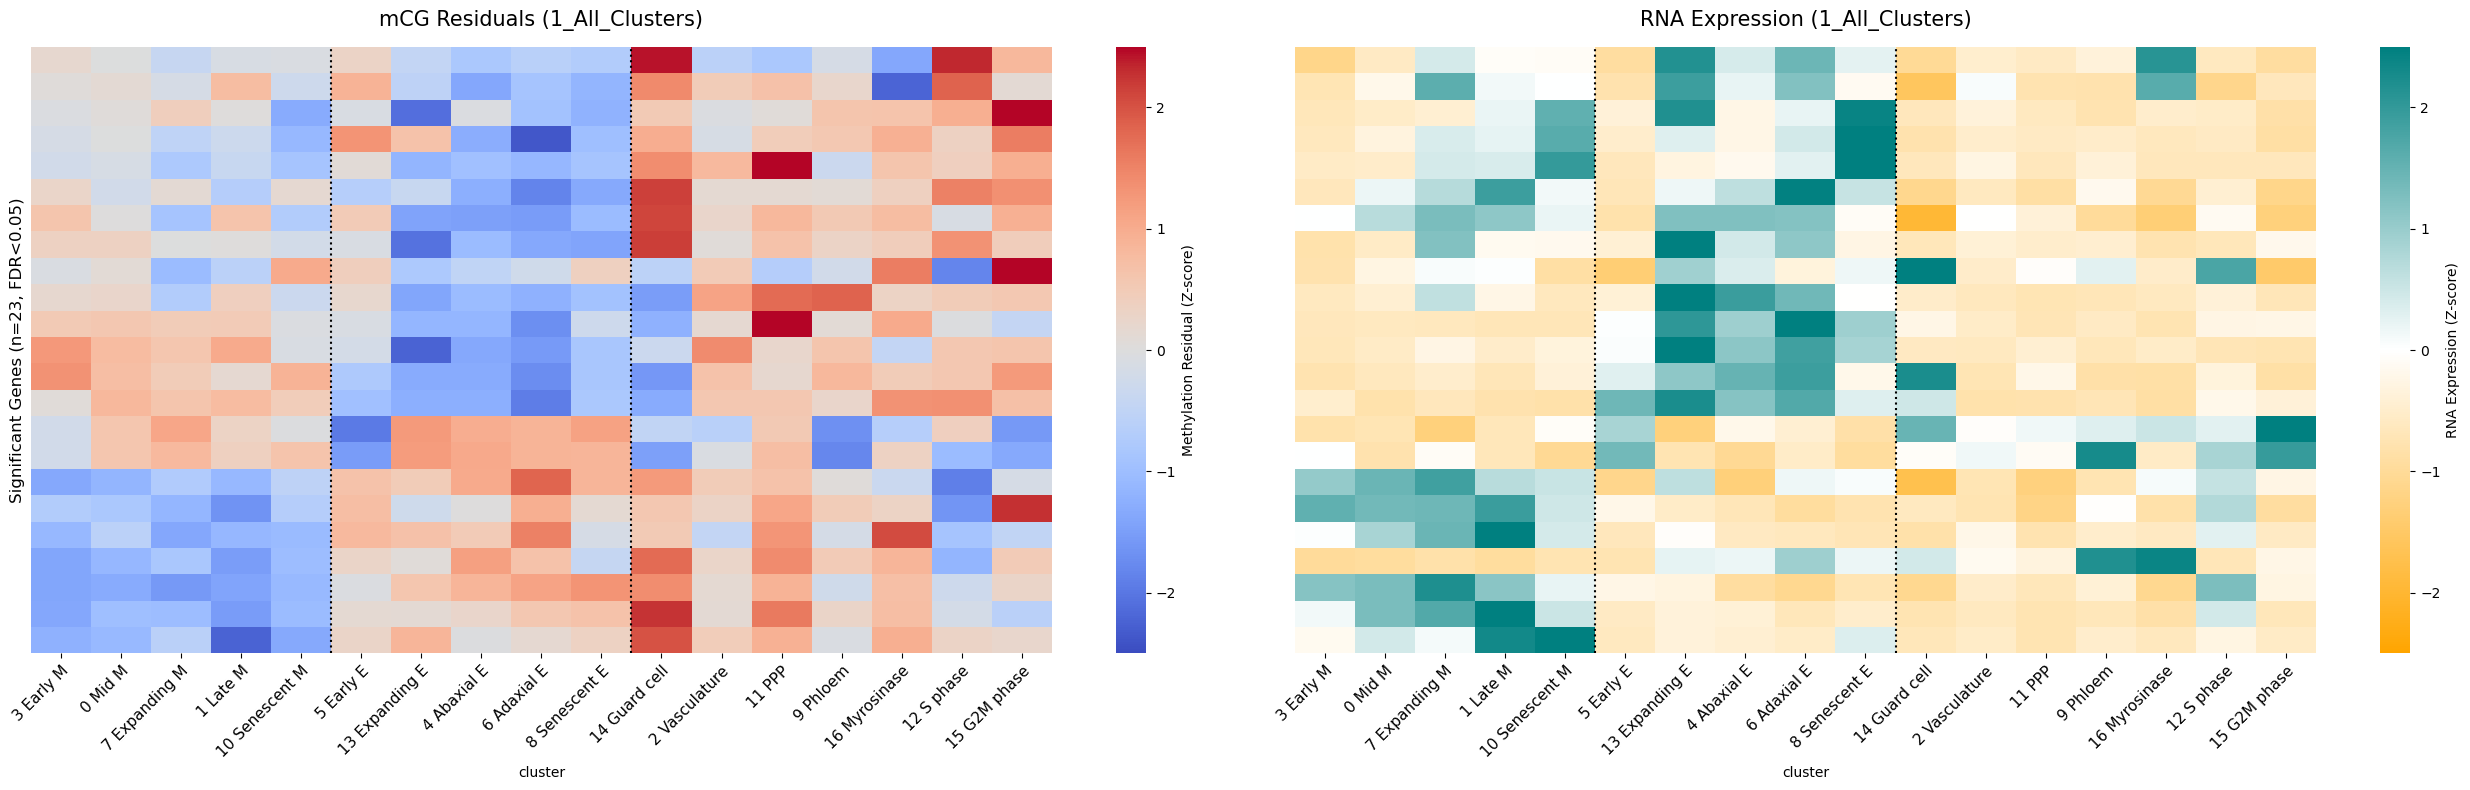

Processing: 2_Meta_States...
  -> Found 2 significant inverse genes.


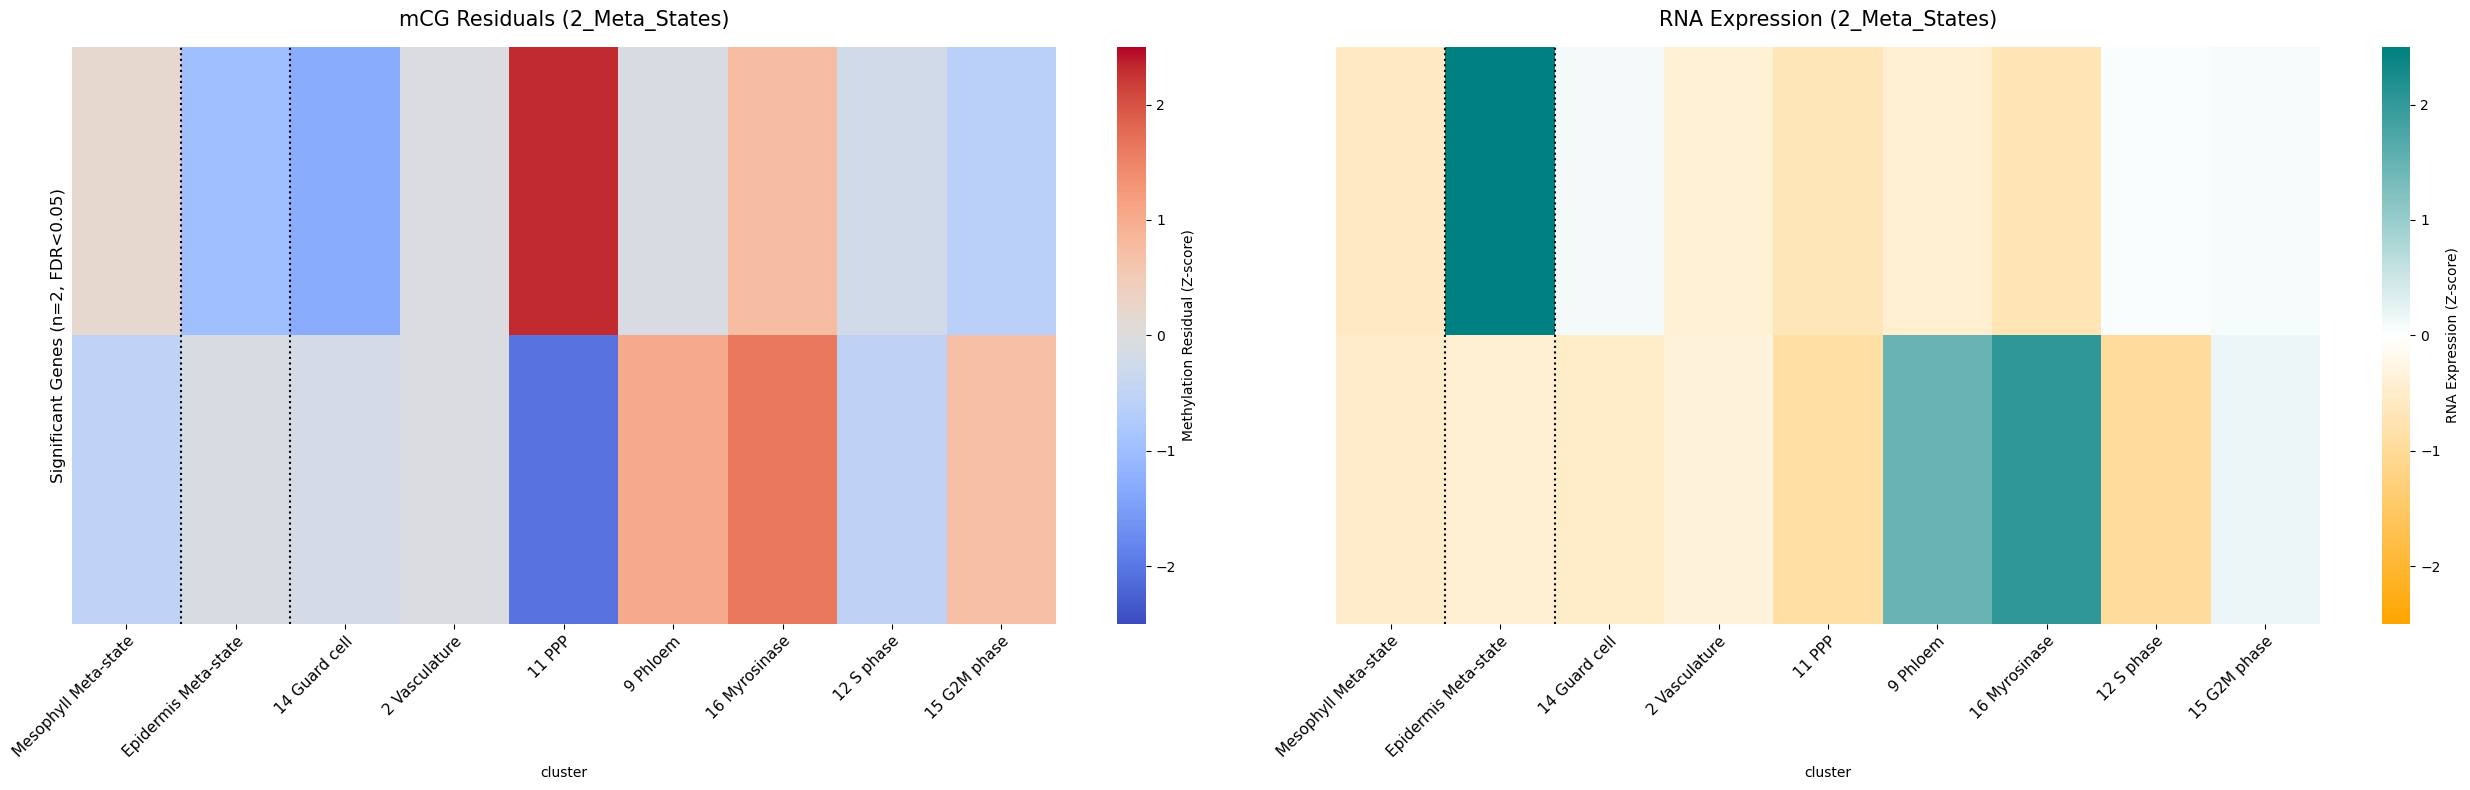

Processing: 3_Mesophyll_Only...
  -> Found 18 significant inverse genes.


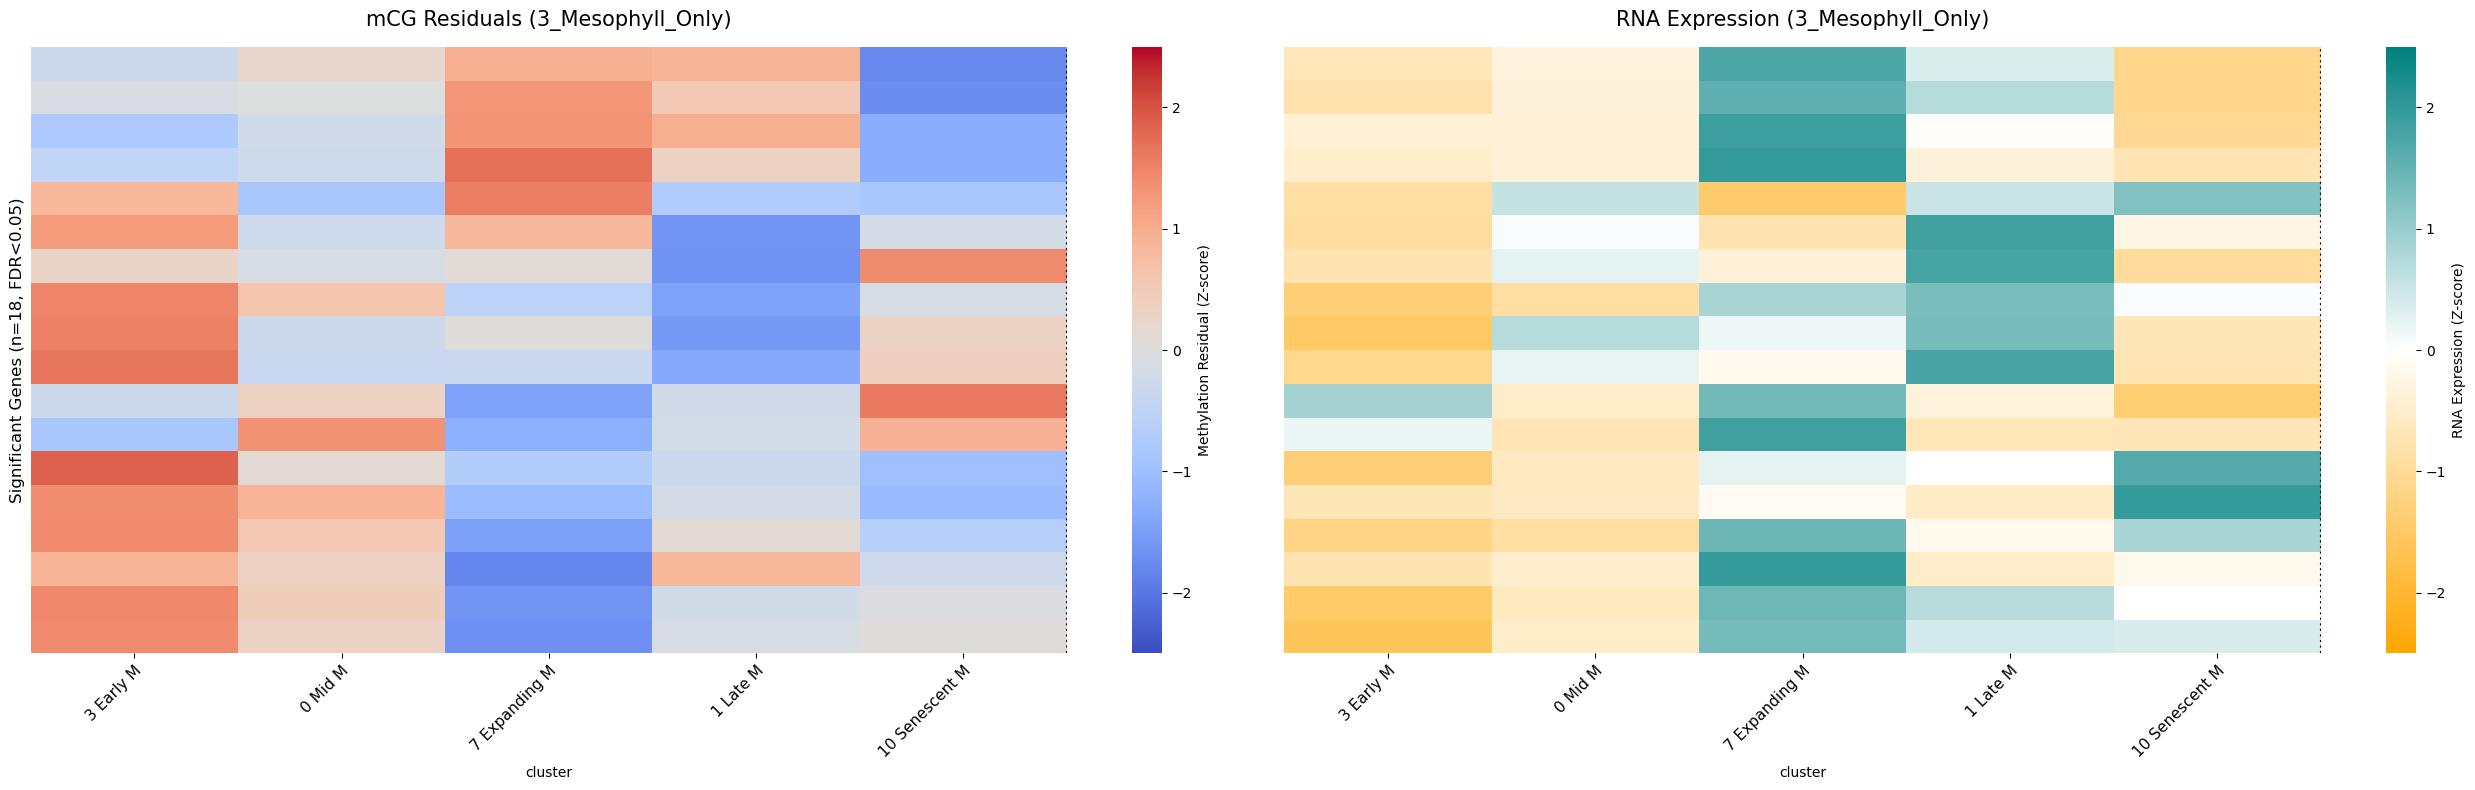

Processing: 4_Epidermis_Only...
  -> Found 15 significant inverse genes.


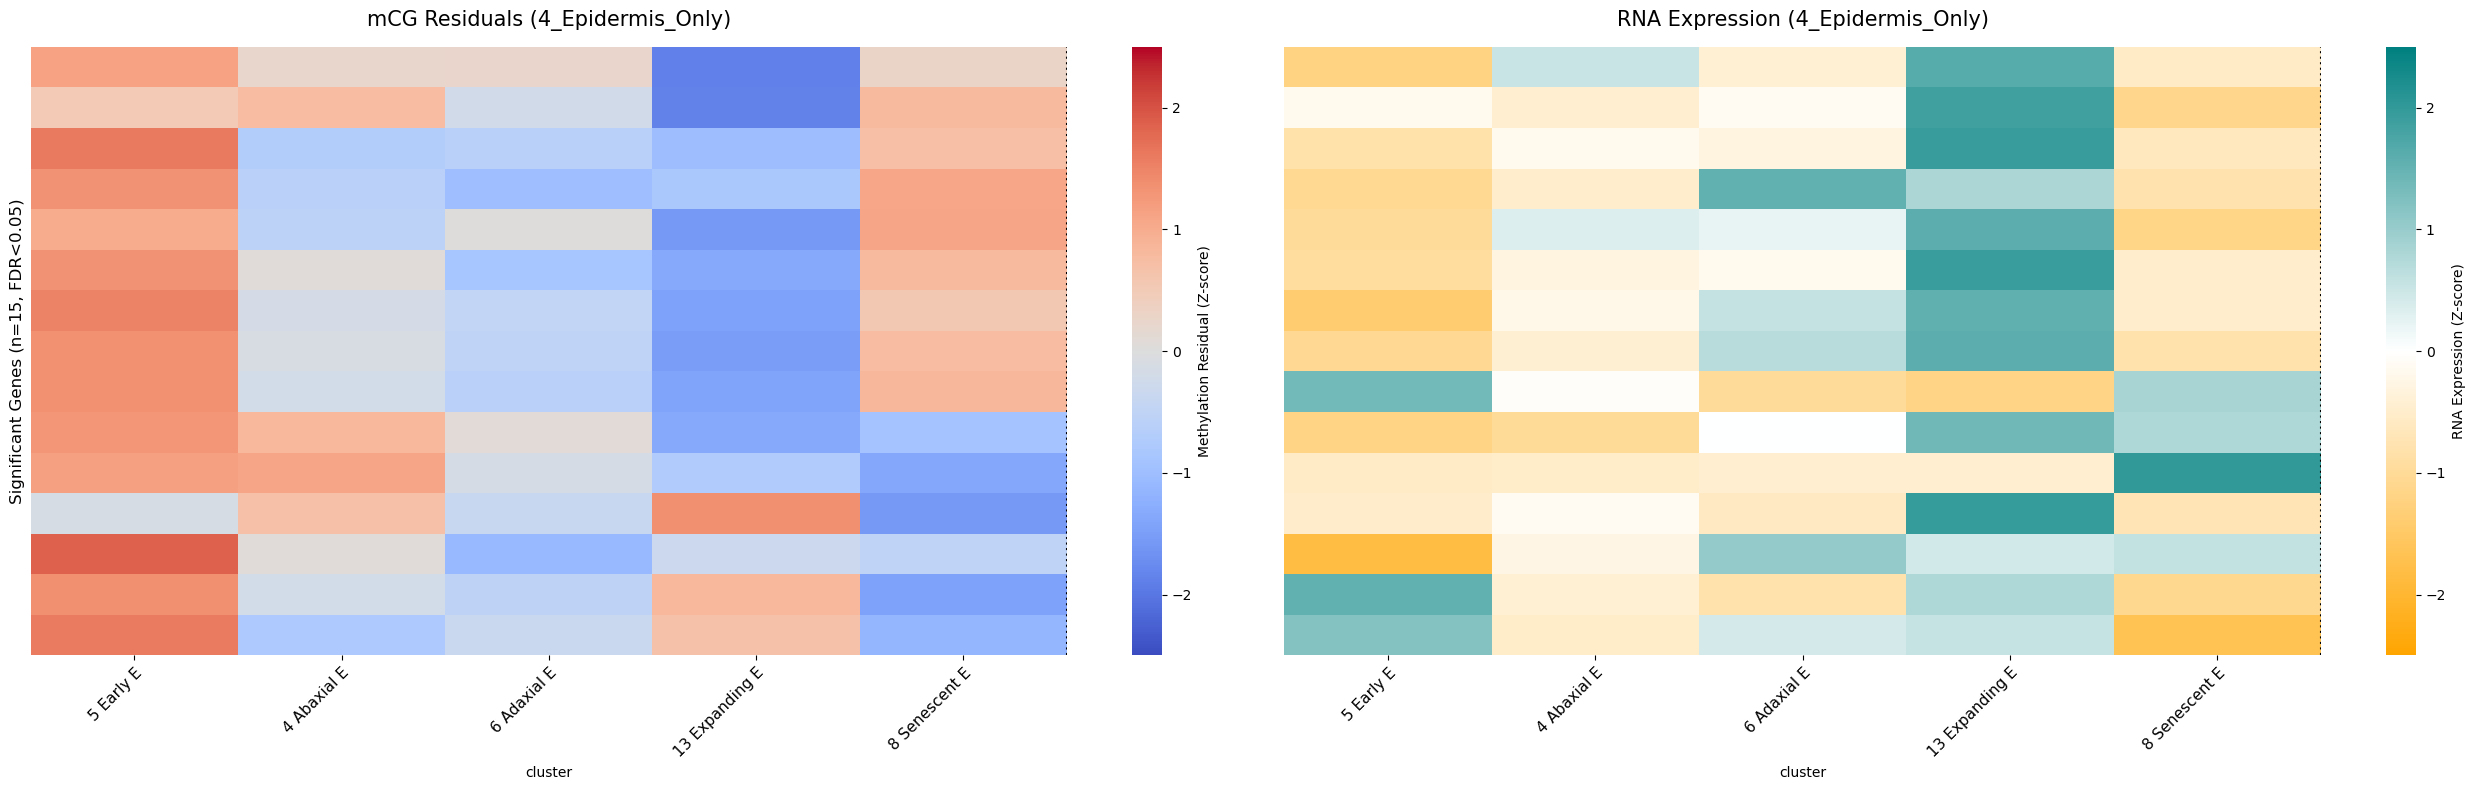

Processing: 5_Non_Meso_Epi...
  -> Skipping 5_Non_Meso_Epi: No genes passed the FDR < 0.05 threshold.
Processing: 6_Terminal_Non_Meso_Epi...
  -> Found 19 significant inverse genes.


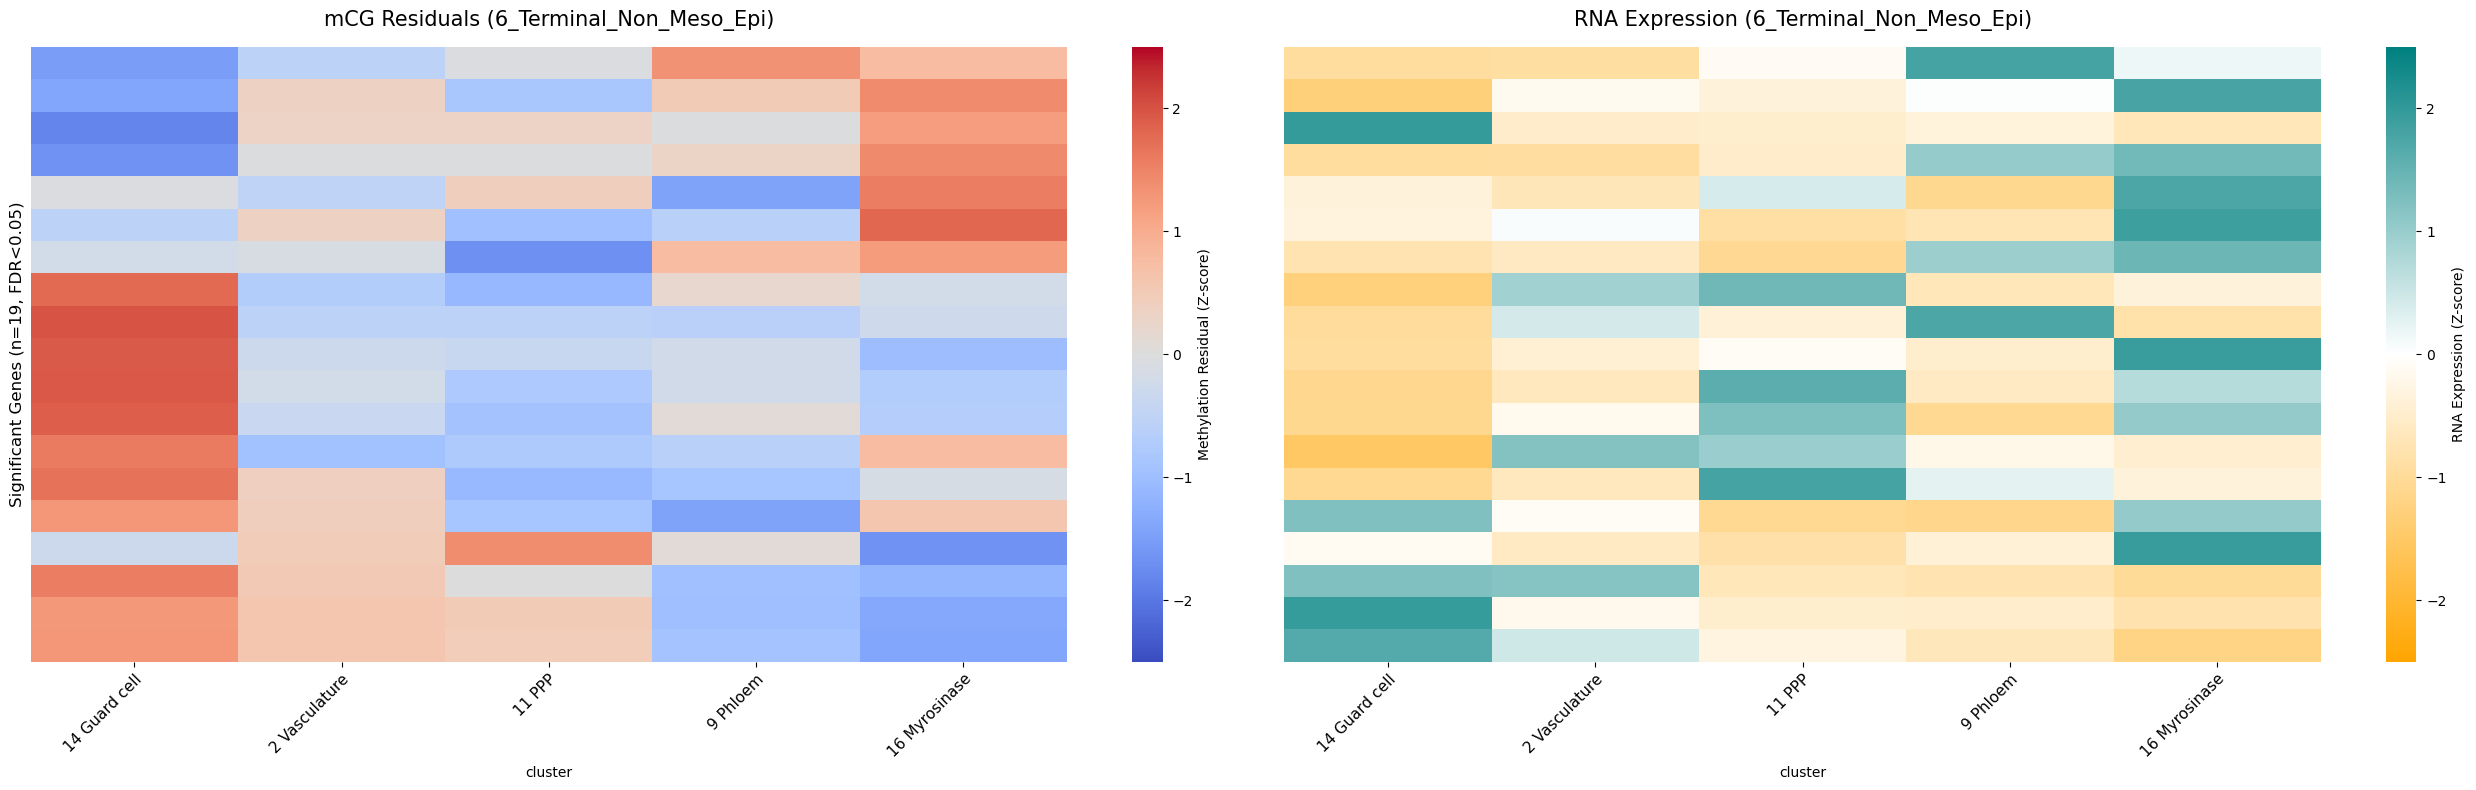

Processing: 7_Terminal_Ex_Guard...
  -> Found 66 significant inverse genes.


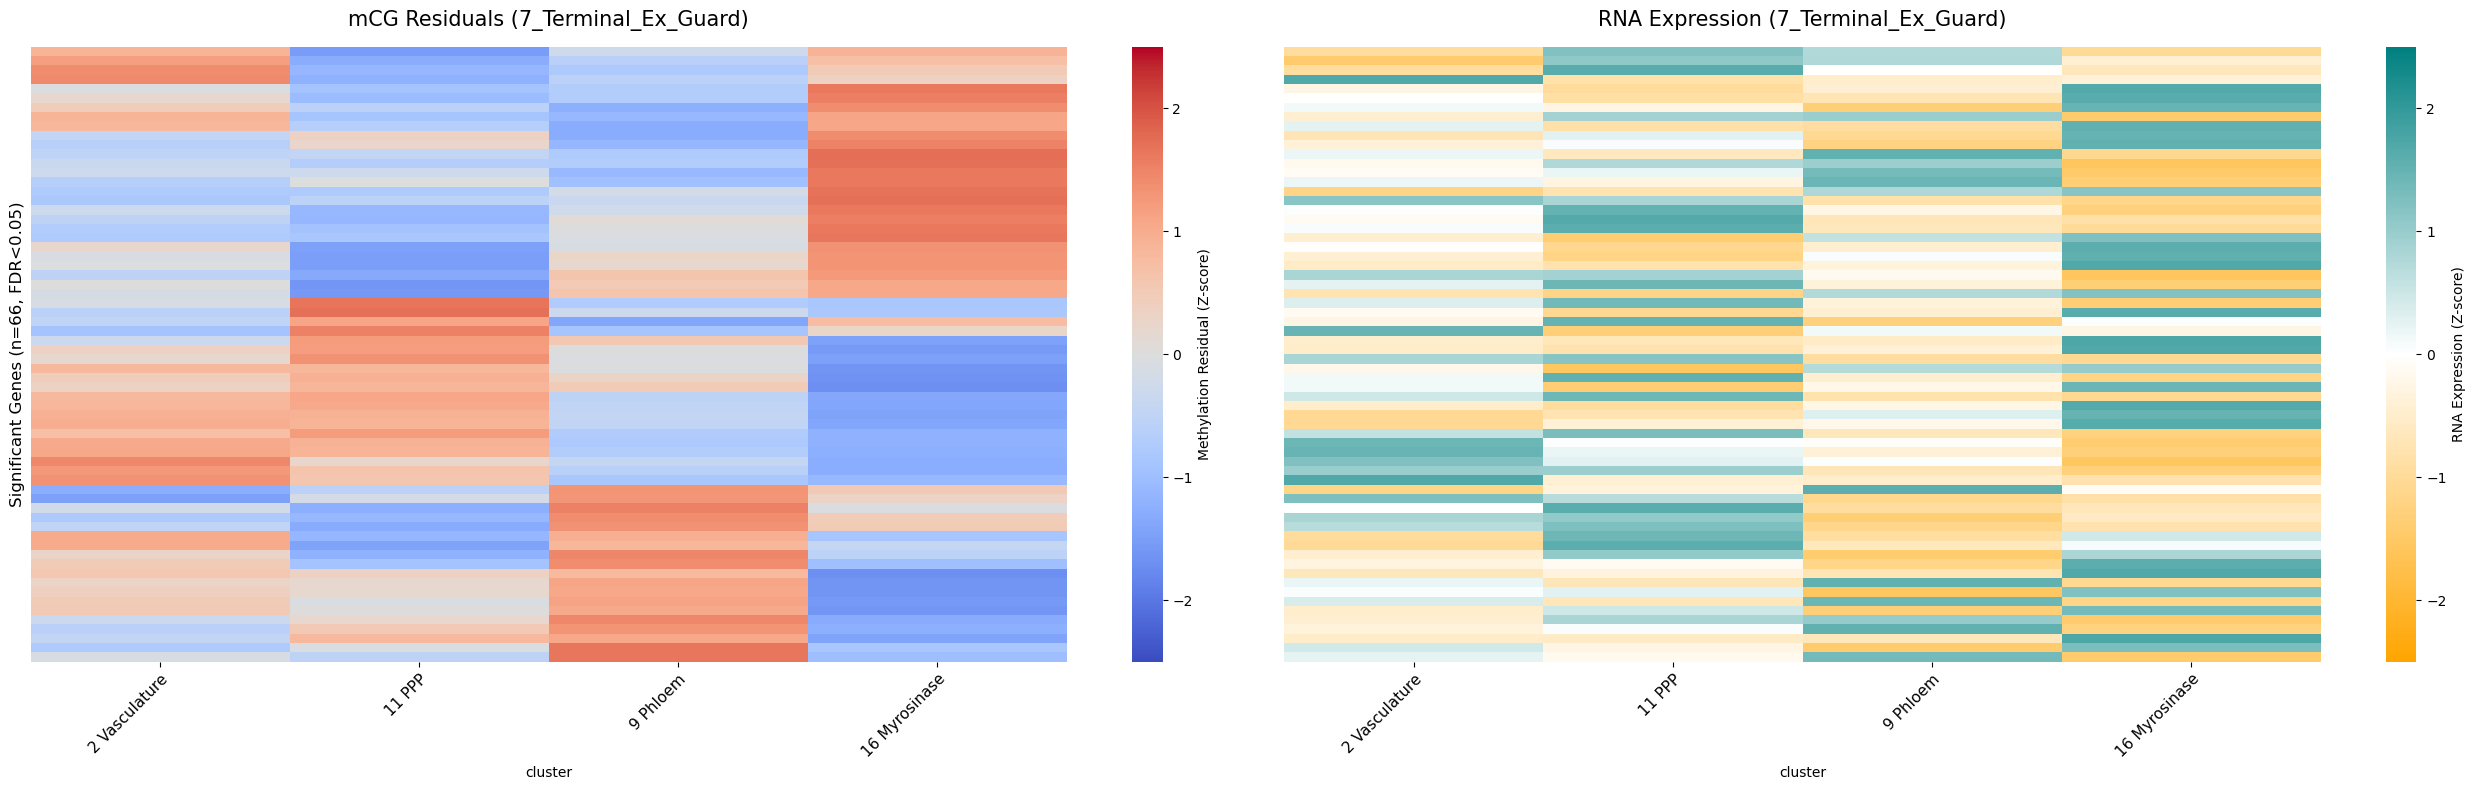

Processing: 8_All_Ex_Guard_G2M...
  -> Found 29 significant inverse genes.


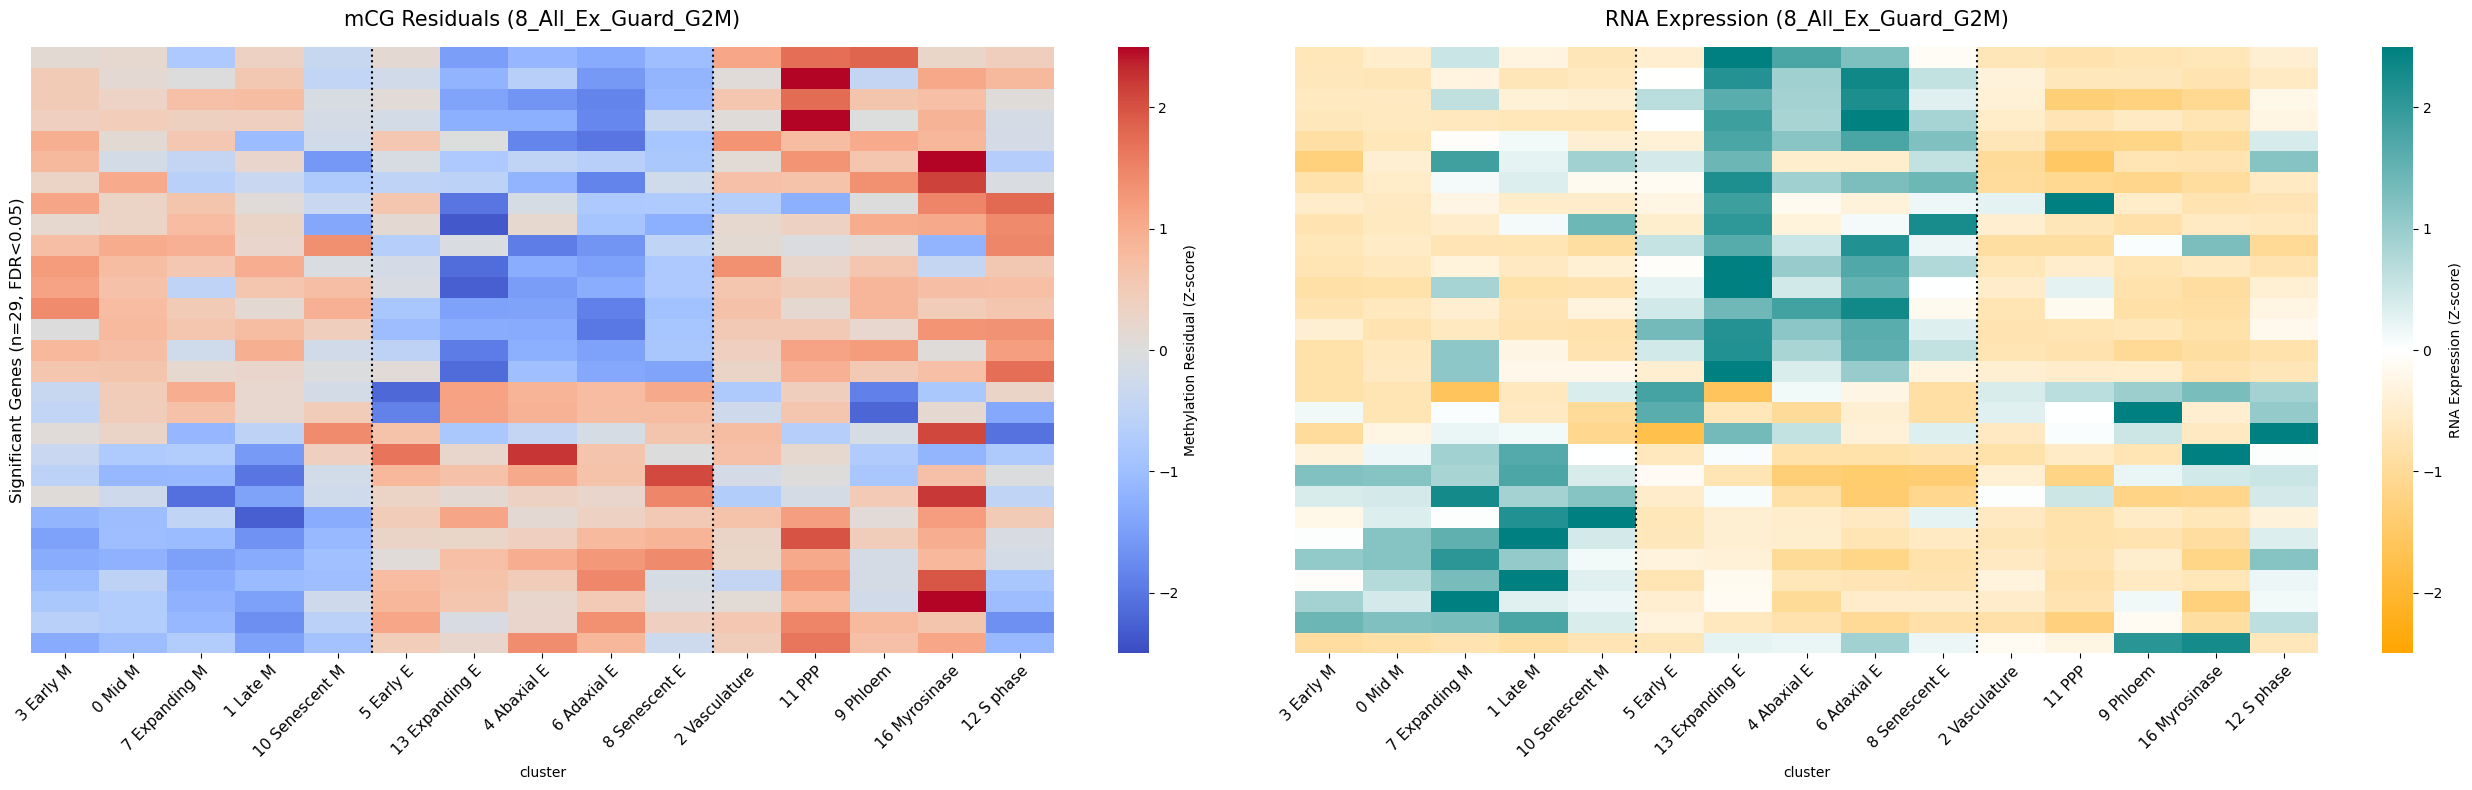

Processing: 9_Meso_and_Epi...
  -> Found 10 significant inverse genes.


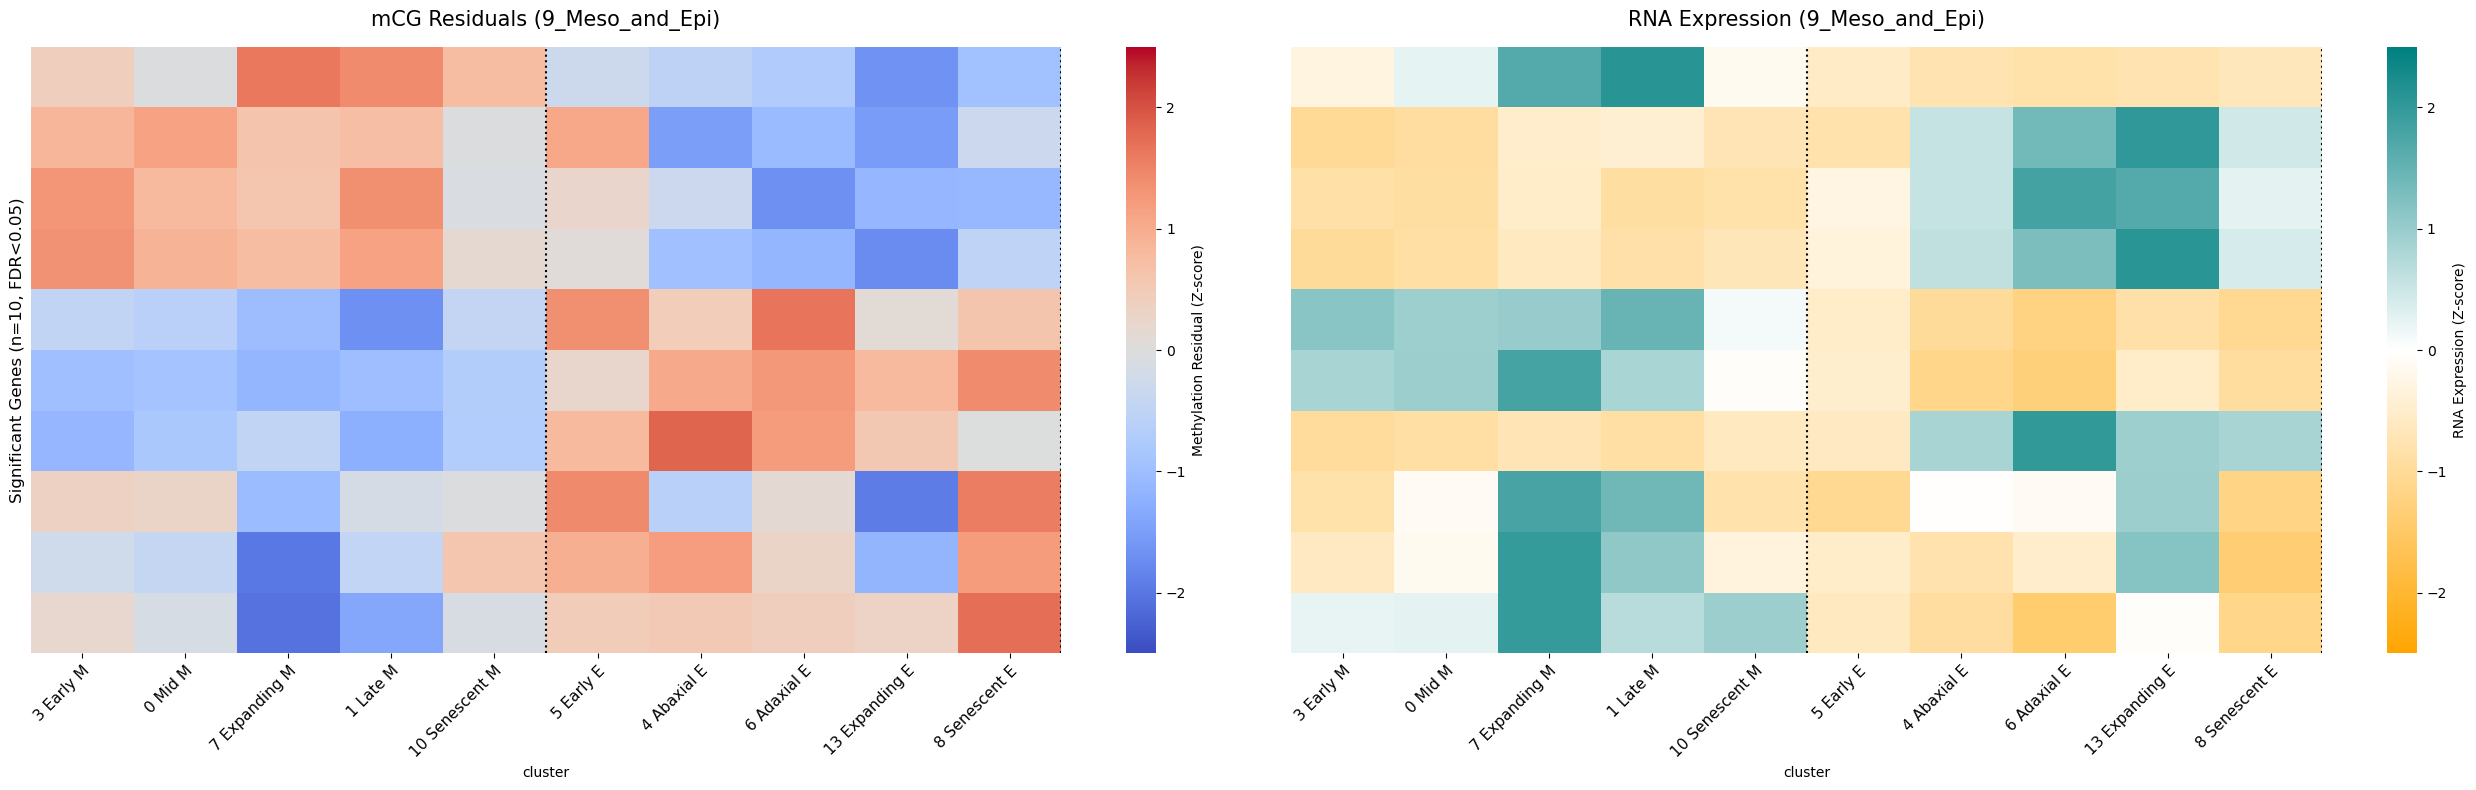


Success! All 9 significant-only heatmap pairs have been generated and saved.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import zscore
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
import os

# Create output directory if it doesn't exist
os.makedirs("/ceph/MethDev/pbio/kay/figures/heatmaps", exist_ok=True)

# 1. Define mappings and expand them to catch any float/int column quirks
base_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
cluster_mapping = {}
for k, v in base_mapping.items():
    cluster_mapping[k] = v
    cluster_mapping[str(k)] = v
    cluster_mapping[float(k)] = v

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 2. Prepare the base dataframes using the renamed string columns
vis_meth_base = final_meth_df.rename(columns=cluster_mapping)
vis_rna_base = final_rna_df.rename(columns=cluster_mapping)

valid_cols = [c for c in cluster_order if c in vis_meth_base.columns]
vis_meth_base = vis_meth_base[valid_cols]
vis_rna_base = vis_rna_base[valid_cols]

# 3. Define specific groupings
mesophyll_clusters = [c for c in ['3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M'] if c in valid_cols]
epidermis_clusters = [c for c in ['5 Early E', '4 Abaxial E', '6 Adaxial E', '13 Expanding E', '8 Senescent E'] if c in valid_cols]

# Pre-calculate the Meta-States DataFrames (Analysis 2) using pseudo-bulk means
meth_meta = vis_meth_base.copy()
rna_meta = vis_rna_base.copy()

if mesophyll_clusters:
    meth_meta['Mesophyll Meta-state'] = meth_meta[mesophyll_clusters].mean(axis=1)
    rna_meta['Mesophyll Meta-state'] = rna_meta[mesophyll_clusters].mean(axis=1)
if epidermis_clusters:
    meth_meta['Epidermis Meta-state'] = meth_meta[epidermis_clusters].mean(axis=1)
    rna_meta['Epidermis Meta-state'] = rna_meta[epidermis_clusters].mean(axis=1)

meth_meta = meth_meta.drop(columns=mesophyll_clusters + epidermis_clusters)
rna_meta = rna_meta.drop(columns=mesophyll_clusters + epidermis_clusters)

meta_order = []
if mesophyll_clusters: meta_order.append('Mesophyll Meta-state')
if epidermis_clusters: meta_order.append('Epidermis Meta-state')
meta_order += [c for c in valid_cols if c not in mesophyll_clusters + epidermis_clusters]

meth_meta = meth_meta[meta_order]
rna_meta = rna_meta[meta_order]

# 4. Define the 9 Subsets for the loop
analyses = {
    "1_All_Clusters": valid_cols,
    "2_Meta_States": meta_order,
    "3_Mesophyll_Only": mesophyll_clusters,
    "4_Epidermis_Only": epidermis_clusters,
    "5_Non_Meso_Epi": [c for c in valid_cols if c in ['14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', '16 Myrosinase', '12 S phase', '15 G2M phase']],
    "6_Terminal_Non_Meso_Epi": [c for c in valid_cols if c in ['14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', '16 Myrosinase']],
    "7_Terminal_Ex_Guard": [c for c in valid_cols if c in ['2 Vasculature', '11 PPP', '9 Phloem', '16 Myrosinase']],
    "8_All_Ex_Guard_G2M": [c for c in valid_cols if c not in ['14 Guard cell', '15 G2M phase']],
    "9_Meso_and_Epi": mesophyll_clusters + epidermis_clusters
}

def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5).fillna(0) # Added fillna(0) for safety

# Orange for low, White for middle, Teal for high
rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal", ["orange", "white", "teal"])

# ==========================================
# 5. Master Execution Loop (With FDR Filter)
# ==========================================
for plot_name, cols in analyses.items():
    print(f"Processing: {plot_name}...")
    
    # Target the correct dataframe subset
    if plot_name == "2_Meta_States":
        sub_meth = meth_meta
        sub_rna = rna_meta
    else:
        sub_meth = vis_meth_base[cols]
        sub_rna = vis_rna_base[cols]
        
    # --- Intersect with Hazel's List ---
    current_hazel = sub_meth.index.intersection(hazel_genes)
    
    valid_genes = []
    correlations = []
    p_values = []
    
    # --- 1. Calculate Correlation and P-Values ---
    for gene in current_hazel:
        r_vals = sub_rna.loc[gene].values
        m_vals = sub_meth.loc[gene].values
        
        # Skip genes with zero variance in this specific subset
        if np.std(r_vals) > 0 and np.std(m_vals) > 0:
            rho, pval = spearmanr(r_vals, m_vals)
            # Ensure the correlation didn't return a NaN
            if not np.isnan(rho) and not np.isnan(pval):
                valid_genes.append(gene)
                correlations.append(rho)
                p_values.append(pval)
            
    if len(valid_genes) == 0:
        print(f"  -> Skipping {plot_name}: No valid genes found with variance > 0.")
        continue
        
    # --- 2. Apply FDR Correction ---
    stats_df = pd.DataFrame({'rho': correlations, 'pval': p_values}, index=valid_genes)
    stats_df['fdr'] = multipletests(stats_df['pval'], method='fdr_bh')[1]
    
    # Filter: Must be significant (FDR < 0.05) AND an inverse relationship (rho < 0)
    sig_genes = stats_df[stats_df['fdr'] < 0.05].index
    
    if len(sig_genes) == 0:
        print(f"  -> Skipping {plot_name}: No genes passed the FDR < 0.05 threshold.")
        continue
        
    print(f"  -> Found {len(sig_genes)} significant inverse genes.")
    
    # --- 3. Z-Score Generation ---
    vis_meth_z = prepare_zscore(sub_meth, sig_genes)
    vis_rna_z = prepare_zscore(sub_rna, sig_genes)
    
    # --- 4. Hierarchical Clustering ---
    if len(sig_genes) > 1:
        row_linkage = hc.linkage(sp.distance.pdist(vis_meth_z.values), method='ward')
        row_order = hc.leaves_list(row_linkage)
        clustered_genes = vis_meth_z.index[row_order]
    else:
        clustered_genes = vis_meth_z.index # Fallback if only 1 gene survives
    
    vis_meth_clustered = vis_meth_z.loc[clustered_genes]
    vis_rna_clustered = vis_rna_z.loc[clustered_genes]
    
    # --- 5. Plotting ---
    # Using the fixed dynamic sizing to prevent vertical stretching
    plot_height = max(8, len(sig_genes) * 0.05) # Slightly tweaked multiplier for clean squares
    plot_width = 26 
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(plot_width, plot_height), gridspec_kw={'width_ratios': [1, 1]})

    # Methylation Heatmap (Coolwarm)
    sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
                vmin=-2.5, vmax=2.5, rasterized=True,
                cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
    ax1.set_title(f"mCG Residuals ({plot_name})", fontsize=15, pad=15)
    ax1.set_ylabel(f"Significant Genes (n={len(sig_genes)}, FDR<0.05)", fontsize=12)
    
    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax1.tick_params(axis='x', labelsize=11)

    # RNA Expression Heatmap (Orange-White-Teal)
    sns.heatmap(vis_rna_clustered, cmap=rna_cmap, center=0, ax=ax2, 
                vmin=-2.5, vmax=2.5, rasterized=True,
                cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
    ax2.set_title(f"RNA Expression ({plot_name})", fontsize=15, pad=15)
    
    ax2.set_xticks(ax2.get_xticks())
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax2.tick_params(axis='x', labelsize=11)

    # Dynamic Dividers 
    divider_positions = []
    for i, col_name in enumerate(cols):
        if "Senescent M" in col_name or "Senescent E" in col_name or "Meta-state" in col_name:
            divider_positions.append(i + 1)
            
    for ax in [ax1, ax2]:
        for pos in divider_positions:
            ax.axvline(pos, color='black', lw=1.5, linestyle=':')

    plt.tight_layout()
    
    # Save the SVG
    plt.savefig(f"/ceph/MethDev/pbio/kay/figures/heatmaps/rna_meth_sig05_{plot_name}_c1038.svg", format="svg", dpi=300, bbox_inches="tight")
    
    plt.show()
    plt.close() 
    
print("\nSuccess! All 9 significant-only heatmap pairs have been generated and saved.")

In [14]:
# Create a dictionary to store the full stats dataframe for every group
group_stats = {}

for plot_name, cols in analyses.items():
    if plot_name == "2_Meta_States":
        sub_meth = meth_meta
        sub_rna = rna_meta
    else:
        sub_meth = vis_meth_base[cols]
        sub_rna = vis_rna_base[cols]
        
    current_hazel = sub_meth.index.intersection(hazel_genes)
    
    valid_genes, correlations, p_values = [], [], []
    
    for gene in current_hazel:
        r_vals = sub_rna.loc[gene].values
        m_vals = sub_meth.loc[gene].values
        
        if np.std(r_vals) > 0 and np.std(m_vals) > 0:
            rho, pval = spearmanr(r_vals, m_vals)
            if not np.isnan(rho) and not np.isnan(pval):
                valid_genes.append(gene)
                correlations.append(rho)
                p_values.append(pval)
                
    if len(valid_genes) > 0:
        # Build the dataframe and calculate FDR
        df = pd.DataFrame({'rho': correlations, 'pval': p_values}, index=valid_genes)
        df['fdr'] = multipletests(df['pval'], method='fdr_bh')[1]
        
        # Sort by best correlation (most negative)
        df = df.sort_values('rho')
        
        # Save to our dictionary
        group_stats[plot_name] = df

# ==========================================
# INSPECTION PRINTOUT
# ==========================================
for name, df in group_stats.items():
    # Count how many actually passed the strict thresholds
    passed_strict = len(df[(df['fdr'] < 0.05) & (df['rho'] < 0)])
    
    print("=" * 60)
    print(f"📊 GROUP: {name}")
    print(f"Total valid genes tested: {len(df)}")
    print(f"Genes passing FDR < 0.05 & Rho < 0: {passed_strict}")
    print("-" * 60)
    print("TOP 10 STRONGEST INVERSE CORRELATIONS (Regardless of FDR):")
    # Display the top 10 most negative rho values to see what the raw p-values look like
    display(df[df['rho'] < 0].head(10))
    print("\n")

📊 GROUP: 1_All_Clusters
Total valid genes tested: 817
Genes passing FDR < 0.05 & Rho < 0: 22
------------------------------------------------------------
TOP 10 STRONGEST INVERSE CORRELATIONS (Regardless of FDR):


,rho,pval,fdr
AT4G01130,-0.904180,6.362151e-07,0.000520
AT4G30400,-0.875000,4.280116e-06,0.001748
AT3G26290,-0.843137,2.132810e-05,0.005808
AT2G34430,-0.833333,3.261049e-05,0.006661
AT1G62030,-0.817903,6.040722e-05,0.009871
AT2G07681,-0.806867,9.075647e-05,0.011207
AT2G07698,-0.801471,1.097353e-04,0.011207
AT4G17090,-0.801471,1.097353e-04,0.011207
AT5G04870,-0.784314,1.936516e-04,0.017579
AT5G52060,-0.776961,2.433153e-04,0.019879




📊 GROUP: 2_Meta_States
Total valid genes tested: 817
Genes passing FDR < 0.05 & Rho < 0: 1
------------------------------------------------------------
TOP 10 STRONGEST INVERSE CORRELATIONS (Regardless of FDR):


,rho,pval,fdr
AT4G30400,-0.950000,0.000088,0.035795
AT4G08850,-0.933333,0.000236,0.064243
AT1G73630,-0.922612,0.000393,0.068985
AT5G15420,-0.916667,0.000507,0.068985
AT3G59950,-0.916667,0.000507,0.068985
AT5G66050,-0.900000,0.000943,0.096310
AT5G04267,-0.894614,0.001127,0.102307
AT1G70790,-0.866667,0.002495,0.152830
AT1G53500,-0.866667,0.002495,0.152830
AT4G01130,-0.861932,0.002806,0.152830




📊 GROUP: 3_Mesophyll_Only
Total valid genes tested: 815
Genes passing FDR < 0.05 & Rho < 0: 14
------------------------------------------------------------
TOP 10 STRONGEST INVERSE CORRELATIONS (Regardless of FDR):


...

,rho,pval,fdr
AT5G67385,-1.0,0.0,0.0
AT5G45490,-1.0,0.0,0.0
AT5G35740,-1.0,0.0,0.0
AT1G34060,-1.0,0.0,0.0
AT1G50430,-1.0,0.0,0.0
AT1G66200,-1.0,0.0,0.0
AT4G37610,-1.0,0.0,0.0
AT4G34140,-1.0,0.0,0.0
AT4G32175,-1.0,0.0,0.0
AT1G74090,-1.0,0.0,0.0




📊 GROUP: 8_All_Ex_Guard_G2M
Total valid genes tested: 817
Genes passing FDR < 0.05 & Rho < 0: 28
------------------------------------------------------------
TOP 10 STRONGEST INVERSE CORRELATIONS (Regardless of FDR):


,rho,pval,fdr
AT4G01130,-0.891868,0.000008,0.003755
AT3G26290,-0.889286,0.000009,0.003755
AT4G30400,-0.875000,0.000020,0.005317
AT1G45191,-0.867857,0.000028,0.005621
AT2G34430,-0.839286,0.000091,0.014930
AT1G28440,-0.825000,0.000153,0.016293
AT4G17090,-0.825000,0.000153,0.016293
AT5G52060,-0.821429,0.000173,0.016293
AT1G29460,-0.817857,0.000195,0.016293
AT5G35740,-0.814286,0.000219,0.016293




📊 GROUP: 9_Meso_and_Epi
Total valid genes tested: 817
Genes passing FDR < 0.05 & Rho < 0: 8
------------------------------------------------------------
TOP 10 STRONGEST INVERSE CORRELATIONS (Regardless of FDR):


,rho,pval,fdr
AT2G33060,-0.975758,0.000001,0.001199
AT1G23480,-0.939394,0.000055,0.022402
AT3G47610,-0.915152,0.000204,0.041763
AT4G01130,-0.915152,0.000204,0.041763
AT4G15760,-0.903030,0.000344,0.044293
AT1G74320,-0.890909,0.000542,0.044293
AT2G34430,-0.890909,0.000542,0.044293
AT5G40850,-0.890909,0.000542,0.044293
AT1G45191,-0.878788,0.000814,0.060448
AT1G62030,-0.866667,0.001174,0.068484
